# Parameter tuning handbook

## Introduction to the DYNAP-SE1 board and API


### 1. Import Samna

Import Samna and all other necessary packages

In [1]:
import samna
import samna.dynapse1 as dyn1

import sys
sys.path.append("..")


from dynapse1constants import *

import dynapse1utils as ut
import netgen as n
from netgen import Neuron
import time
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# open without GUI (for board connected to the remote machine)
model, _ = ut.open_dynapse1(gui=True, select_device=False)

# open with GUI (only with the board connected locally)
#model, gui_thread = ut.open_dynapse1(gui=True)

[0]:  Bus 1 Device 9 Dynapse1DevKit serial_number 00000002
0 Dynapse1Wrapper created! libcaer init...
Clearing chip 0... DONE.
Clearing chip 1... DONE.
Clearing chip 2... DONE.
Clearing chip 3... DONE.
Visualizer start command:  /home/dzenn/anaconda3/envs/dynapse1/bin/python -c "import samna, samnagui; samnagui.runVisualizer(0.75, 0.75,         'tcp://0.0.0.0:33335', 'tcp://0.0.0.0:33336', 3)"
GUI receiving port: tcp://0.0.0.0:40061
GUI node ID: 3
Selected device: 00000002
Sender port: tcp://0.0.0.0:33336
Receiver port: tcp://0.0.0.0:33335
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2


#### 1.1 Open the bias GUI (only if the Dynap-SE1 board is connected locally)

In [ ]:


#gui = sliderGui(model)

In [15]:
import importlib
import dynapse1utils
importlib.reload(dynapse1utils)

import dynapse1utils as ut

In [7]:
from ipywidgets import interact, interactive, fixed, interact_manual

In [3]:
from ipywidgets import interact

In [6]:
def f(x, y):
    return x, y

In [8]:
interact(f, x=10, y=1);

interactive(children=(IntSlider(value=10, description='x', max=30, min=-10), IntSlider(value=1, description='y…

In [23]:
alert('Alert')

NameError: name 'alert' is not defined

In [5]:
import jupyterlab_widgets

In [9]:
@interact(x=True, y=1.0)
def g(x, y):
    return (x, y)

interactive(children=(Checkbox(value=True, description='x'), FloatSlider(value=1.0, description='y', max=3.0, …

In [9]:
from IPython.display import display
def f(a, b):
    display(a + b)
    return a+b

In [11]:
w = interactive(f, a=10, b=20)

30

In [15]:
jupyter labextension list

SyntaxError: invalid syntax (3654186813.py, line 1)

In [15]:
%matplotlib notebook
display(w)

interactive(children=(IntSlider(value=10, description='a', max=30, min=-10), IntSlider(value=20, description='…

In [4]:
# create triplets of indices for neurons to monitor
chip_id=1
core_id=0

neurons_to_monitor = np.arange(10, 100)

neurons_to_monitor_triplets = [(chip_id, core_id, n_id) for n_id in neurons_to_monitor]
event_graph, filter_node, sink_node = ut.create_neuron_select_graph(model, neurons_to_monitor_triplets)

event_graph.start()

True

In [5]:
from collections import deque
buffered_events = deque(maxlen=300)

In [6]:
def update_events(sink_node):
    buffered_events.extend(sink_node.get_events())

In [23]:
len(update_events())

300

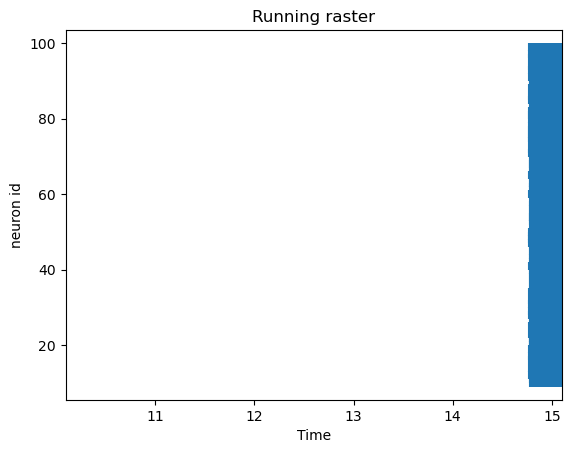

In [112]:
from matplotlib import pyplot as plt
from IPython import display

%matplotlib inline

fig, ax = plt.subplots(1)
ax.set(xlabel=f'Time', ylabel='neuron id',
       title='Running raster')

api = model.get_dynapse1_api()
api.reset_timestamp()

plot_raster = ax.scatter(timestamps_s, event_ids, marker='|')
#set_dc_interactive(model, 1, 0, mode="index")

while True:
    try:
        update_events(sink_node)
    
        event_ids = np.array([evt.neuron_id for evt in buffered_events])
        timestamps_us = np.array([evt.timestamp for evt in buffered_events])
        #timestamps_us[:]-=timestamps_us[0]
        timestamps_s = timestamps_us*1e-06
        
        
        #print(f"update {timestamps_s[:5]}")

        plot_raster.set_offsets(np.c_[timestamps_s, event_ids])
        ax.set_xlim(timestamps_s[-1]-5, timestamps_s[-1])
        
        plt.pause(0.01)
        fig.canvas.draw()
        #display.clear_output(wait=True)
        display.display(fig, clear=True);
        
    except KeyboardInterrupt:
        break

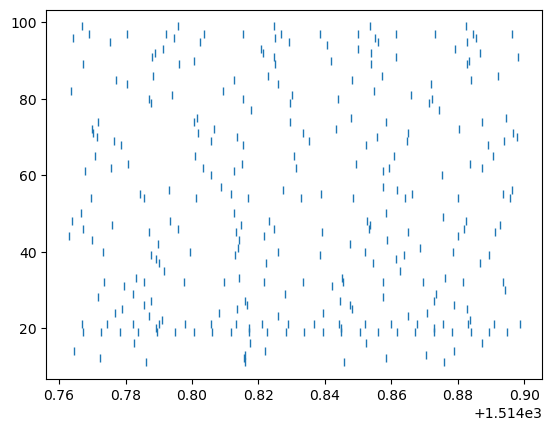

In [34]:
fig, ax = plt.subplots(1)
ax.plot(timestamps_s, event_ids, '|')

In [17]:
%matplotlib notebook
from ipywidgets import *
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2 * np.pi)
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
line, = ax.plot(x, np.sin(x))

def update(w = 1.0):
    line.set_ydata(np.sin(w * x))
    fig.canvas.draw_idle()

interact(update)

<IPython.core.display.Javascript object>

interactive(children=(FloatSlider(value=1.0, description='w', max=3.0, min=-1.0), Output()), _dom_classes=('wi…

<function __main__.update(w=1.0)>

In [5]:
import ipywidgets as widgets

In [10]:
import ipywidgets
ipywidgets.IntSlider()

IntSlider(value=0)

In [98]:
bias_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=24e+08,
    step=1,
    description='Bias:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

In [9]:
def set_dc_bias(model, chip_id, core_id, x, mode="linear"):
    ut.set_neuron_dc(model, chip_id, core_id, x, mode)
    if mode == "linear":
        bias_value = ut.get_coarse_and_fine_from_linear_bias(x)
    if mode == "index":
        bias_value = ut.set_bias_by_index(x)
    print(f"setting TC bias to C{chip_id}c{core_id}: {bias_value}")

In [3]:
def set_dc_interactive(model, chip_id, core_id, init_bias=0, mode="linear"):
    if mode == "linear":
        max_bias = 24e+08
    elif mode == "index":
        max_bias = 1811
    bias_slider_dc = widgets.IntSlider(
    value=init_bias,
    min=0,
    max=max_bias,
    step=1,
    description=f'C{chip_id}c{core_id} DC:',
    disabled=False,
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='d'
    )
    return interact(lambda x:set_dc_bias(model, chip_id, core_id, x, mode), x=bias_slider_dc)

In [10]:
set_dc_interactive(model, 1, 0, mode="index")

interactive(children=(IntSlider(value=0, description='C1c0 DC:', max=1811), Output()), _dom_classes=('widget-i…

<function __main__.set_dc_interactive.<locals>.<lambda>(x)>

In [41]:
set_tc_interactive()

interactive(children=(IntSlider(value=0, continuous_update=False, description='TC:', max=2400000000), Output()…

<function __main__.set_bias(x)>

In [7]:
def collect_spikes(sink_node, runningFlag):
    while runningFlag[0]:  # Check first element of list
        buffered_events.extend(sink_node.get_events())

In [8]:
import threading

running_flag = [True]  # Use list for mutable flag
spike_thread = threading.Thread(target=collect_spikes, args=(sink_node, running_flag))
spike_thread.daemon = True
spike_thread.start()

In [29]:
def process_ticks(bufferarg):
    items = deque(maxlen=5000)
    while True:
        try:
            # get and remove one item from the end of the deque
            items.extend([bufferarg.popleft()])
        except IndexError:
            # no data in buffer, try again immediately or sleep a little
            break
    return items

In [32]:
import numpy as np
from flask import Flask, jsonify, make_response, request
from time import sleep

from bokeh.models import AjaxDataSource, CustomJS
from bokeh.plotting import figure, show

api = model.get_dynapse1_api()
api.reset_timestamp()

sleep(1)
# Bokeh related code

adapter = CustomJS(code="""
    const result = {x: [], y: []}
    const {points} = cb_data.response
    for (const [x, y] of points) {
        result.x.push(x)
        result.y.push(y)
    }
    return result
""")

source = AjaxDataSource(data_url='http://localhost:5050/data',
                        polling_interval=100, adapter=adapter)

p = figure(height=300, width=800, background_fill_color="lightgrey",
           title="Streaming Spikes via Ajax")
p.circle('x', 'y', source=source)

p.x_range.follow = "end"
p.x_range.follow_interval = 5

# Flask related code

app = Flask(__name__)

def crossdomain(f):
    def wrapped_function(*args, **kwargs):
        resp = make_response(f(*args, **kwargs))
        h = resp.headers
        h['Access-Control-Allow-Origin'] = '*'
        h['Access-Control-Allow-Methods'] = "GET, OPTIONS, POST"
        h['Access-Control-Max-Age'] = str(21600)
        requested_headers = request.headers.get('Access-Control-Request-Headers')
        if requested_headers:
            h['Access-Control-Allow-Headers'] = requested_headers
        return resp
    return wrapped_function

local_evts = process_ticks(buffered_events)
y = deque(maxlen=5000)
x = deque(maxlen=5000)
y.extend([evt.neuron_id for evt in local_evts])
x.extend([evt.timestamp*1e-06 for evt in local_evts])

@app.route('/data', methods=['GET', 'OPTIONS', 'POST'])
@crossdomain
def data():
    #update_events(sink_node)
    local_evts = process_ticks(buffered_events)
    event_ids = [evt.neuron_id for evt in local_evts]
    timestamps_us = [evt.timestamp*1e-06 for evt in local_evts]
    x.extend(timestamps_us)
    y.extend(event_ids)
    #x.extend(timestamps_us)
    #y.extend(event_ids)
    return jsonify(points=list(zip(x,y)))

# show and run

show(p)
#app.run(port=5050)

In [34]:
threading.Thread(target=lambda: app.run(port=5050, debug=True, use_reloader=False)).start()

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5050
Press CTRL+C to quit
127.0.0.1 - - [04/Jun/2025 08:52:23] "OPTIONS /data HTTP/1.1" 200 -
127.0.0.1 - - [04/Jun/2025 08:52:23] "POST /data HTTP/1.1" 200 -


In [21]:
y, x = [evt.neuron_id, evt.timestamp for evt in buffered_events]

SyntaxError: invalid syntax (760485613.py, line 1)

In [72]:
local_evts = process_ticks(buffered_events)
y = [evt.neuron_id for evt in local_evts]
x = [evt.timestamp*1e-06 for evt in local_evts]

print(x, y)

[36.615235999999996, 36.616817999999995, 36.616955, 36.617053, 36.618393, 36.618424999999995, 36.619158999999996, 36.619865, 36.620498999999995, 36.620591999999995, 36.621506, 36.62179, 36.622143, 36.622541999999996, 36.622603, 36.622695, 36.622921, 36.62302, 36.623405, 36.623532, 36.623937, 36.624145999999996, 36.624609, 36.62475, 36.625547, 36.626011, 36.62638, 36.62639, 36.626642, 36.627714999999995, 36.628153999999995, 36.62872, 36.628994999999996, 36.629008, 36.629186, 36.629289, 36.629523999999996, 36.629560999999995, 36.630663, 36.632791999999995, 36.633706, 36.633992, 36.634937, 36.635411, 36.636451, 36.636829999999996, 36.637333, 36.637788, 36.637896, 36.638802, 36.638844999999996, 36.639046, 36.63926, 36.640051, 36.640335, 36.640785, 36.641287999999996, 36.641732, 36.641774, 36.641901, 36.644822, 36.644933, 36.645106999999996, 36.645846999999996, 36.646457999999996, 36.646665, 36.646932, 36.647447, 36.648664, 36.648666999999996, 36.648722, 36.64901, 36.649381999999996, 36.649

In [118]:
# When using the `widget` backend from ipympl,
# fig.canvas is a proper Jupyter interactive widget, which can be embedded in
# an ipywidgets layout. See https://ipywidgets.readthedocs.io/en/stable/examples/Layout%20Templates.html

# One can bound figure attributes to other widget values.
from ipywidgets import AppLayout, FloatSlider

plt.ioff()

slider = FloatSlider(
    orientation='horizontal',
    description='Factor:',
    value=1.0,
    min=0.02,
    max=2.0
)

slider.layout.margin = '0px 30% 0px 30%'
slider.layout.width = '40%'

fig = plt.figure()
fig.canvas.header_visible = False
fig.canvas.layout.min_height = '400px'
plt.title('Plotting: y=sin({} * x)'.format(slider.value))

x = np.linspace(0, 20, 500)

lines = plt.plot(x, np.sin(slider.value * x))

def update_lines(change):
    plt.title('Plotting: y=sin({} * x)'.format(change.new))
    lines[0].set_data(x, np.sin(change.new * x))
    fig.canvas.draw()
    fig.canvas.flush_events()

slider.observe(update_lines, names='value')

AppLayout(
    center=fig.canvas,
    footer=slider,
    pane_heights=[0, 6, 1]
)

AttributeError: 'FigureCanvasAgg' object has no attribute 'layout'

In [116]:
with plt.ioff():
    fig = plt.figure()
im = plt.imshow(example_image_stack[0])

out = widgets.Output()
@out.capture()
def update(change):
    with out:
        if change['name'] == 'value':
            im.set_data(example_image_stack[change['new']])
            fig.canvas.draw_idle
    
    
slider = widgets.IntSlider(value=0, min=0, max=len(parameter)+10)
slider.observe(update)
display(widgets.VBox([slider, fig.canvas]))
display(out)

TraitError: The 'children' trait of a VBox instance contains an Instance of a TypedTuple which expected a Widget, not the FigureCanvasAgg at '0x71f2c69af940'.

In [32]:
interact(set_bias, x=bias_slider);

interactive(children=(IntSlider(value=2070967742, continuous_update=False, description='Bias:', max=2400000000…

In [ ]:
from dynapse_tuning_companion import DynapseTuningCompanion

net_gen = netgen.NetworkGenerator()
DTC = DynapseTuningCompanion(model, net_gen)

In [ ]:
DTC.monitor_neuron(1, 100)

In [ ]:
DTC.connect_spikegen(target_chip_id=1)

In [ ]:
DTC.set_spikegen_rate(50)

In [ ]:
# sweep weight, threshold and voltage peaks





#### 1.2 Monitor single neurons with oscilloscope (if an Agilent oscilloscope is connected)

First, we make the board output the membrane voltage of a specific neuron to the output socket.

**Note:** we specify `chip_id` __[0..3]__ and `neuron_id` __[0..1023]__, but the oscilloscope probe should be connected to the socket of the corresponding **core**.

In [ ]:
api  =  model.get_dynapse1_api()

chip_id = 1
neuron_id = 10

api.monitor_neuron(chip_id, neuron_id)

#### 1.3 Oscilloscope access

Using the `pygetscope` library it is possible to get the traces directly and process the waveforms in python.

Please refer to [PyGetScope ReadMe](https://code.ini.uzh.ch/ncs/libs/pygetscope) for the full class reference.

In [ ]:
from pygetscope.py_scope import PyScope

my_scope = PyScope()

In [ ]:
# Get the waveform from channel 1 and plot it
wf = my_scope.get_waveform(channel=1)

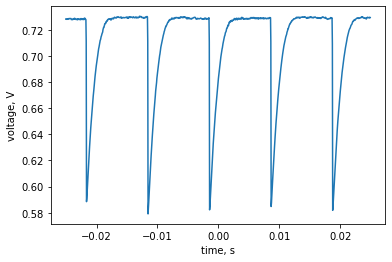

In [115]:
wf2= my_scope.get_waveform(channel=1, instant_plot=True)

## 2. Board Configurations

`configuration` is an object returned by the `model` that keeps track of the **parameters** (or **biases**) set on the board, and the list of **connections**. Between the neurons.

### Let's see what's inside the configuration

Configuration represents state of the device

In [14]:
config1 = model.get_configuration()

In [15]:
dir(config1.chips[0].cores[0])

['__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'chip_id',
 'core_id',
 'from_json',
 'neurons',
 'parameter_group',
 'to_json']

### Check biases in the parameter group

`parameter_group` object of each core contains the values of each parameter with then `param_map` dictionary.

Each parameter (bias) can be set either as a tuple of two values (coarse [0..7], fine [0..255]) or as a single (linear [0..2.4+e08]) value covering the same range.

In [17]:
print("Linear: " + str(config1.chips[1].cores[0].parameter_group.get_linear_parameter('IF_TAU1_N')))
print("Coarse: " + str(config1.chips[1].cores[0].parameter_group.param_map['IF_TAU1_N'].coarse_value))
print("Fine: " + str(config1.chips[1].cores[0].parameter_group.param_map['IF_TAU1_N'].fine_value))

Linear: 2019608.0
Coarse: 4
Fine: 103


In [9]:
param_group = config1.chips[0].cores[0].parameter_group

In [10]:
param_group.param_map.keys()

dict_keys(['IF_AHTAU_N', 'IF_AHTHR_N', 'IF_AHW_P', 'IF_BUF_P', 'IF_CASC_N', 'IF_DC_P', 'IF_NMDA_N', 'IF_RFR_N', 'IF_TAU1_N', 'IF_TAU2_N', 'IF_THR_N', 'NPDPIE_TAU_F_P', 'NPDPIE_TAU_S_P', 'NPDPIE_THR_F_P', 'NPDPIE_THR_S_P', 'NPDPII_TAU_F_P', 'NPDPII_TAU_S_P', 'NPDPII_THR_F_P', 'NPDPII_THR_S_P', 'PS_WEIGHT_EXC_F_N', 'PS_WEIGHT_EXC_S_N', 'PS_WEIGHT_INH_F_N', 'PS_WEIGHT_INH_S_N', 'PULSE_PWLK_P', 'R2R_P'])

### The full list of biases available:

- IF_AHTAU_N - Neuron’s firing threshold adaptation time constant
- IF_AHTHR_N - Neuron’s firing threshold max value
- IF_AHW_P - Neuron’s firing threshold adaptation weight (how much the threshold rises with each spike) 
- IF_BUF_P - N\A
- IF_CASC_N - Enables firing threshold adaptation
- IF_DC_P - DC current injected into a neuron
- IF_NMDA_N - Enable NMDA gating
- IF_RFR_N - Neuron refractory period
- IF_TAU1_N - Main neuron time constant (unless switched to TAU2)
- IF_TAU2_N - Secondary time constant (for every neuron either TAU1 or TAU2 can be selected)
- IF_THR_N - Neuron V_mem gain (not the firing threshold!)
- NPDPIE_TAU_F_P - Fast excitatory (AMPA) synapses time constant
- NPDPIE_TAU_S_P - Slow excitatory (NMDA) synapses time constant
- NPDPIE_THR_F_P - Fast excitatory (AMPA) synapses threshold (i.e. max I_syn value)
- NPDPIE_THR_S_P - Slow excitatory (NMDA) synapses threshold (i.e. max I_syn value)
- NPDPII_TAU_F_P - Fast inhibitory (GABA_A) synapses time constant
- NPDPII_TAU_S_P - Slow inhibitory (GABA_B) synapses time constant
- NPDPII_THR_F_P - Fast inhibitory (GABA_A) synapses threshold ((i.e. max I_syn value)
- NPDPII_THR_S_P - Slow inhibitory (GABA_B) synapses threshold (i.e. max I_syn value)
- PS_WEIGHT_EXC_F_N - Fast excitatory (AMPA) synapse weights
- PS_WEIGHT_EXC_S_N - Slow excitatory (NMDA) synapse weights
- PS_WEIGHT_INH_F_N - Fast inhibitory (GABA_A) synapse weights
- PS_WEIGHT_INH_S_N - Slow inhibitory (GABA_B) synapse weights
- PULSE_PWLK_P - Pulse width for synapses
- R2R_P - N\A


### 2.1 Updating biases on the board

In [11]:
param_group.param_map['IF_TAU1_N'].fine_value = 200
param_group.param_map['IF_TAU1_N'].coarse_value = 6

In [ ]:
# This updated the paramter group of the specific core of the chip.
model.update_parameter_group(param_group, 0, 0)

### 2.2 Neurons

In [17]:
neurons = config1.chips[2].cores[0].neurons

In [18]:
len(neurons)

256

#### Neuron attributes

In [19]:
print(neurons[0].chip_id)
print(neurons[0].core_id)

2
0


# 3. Event Graph: retreiving spikes from the board

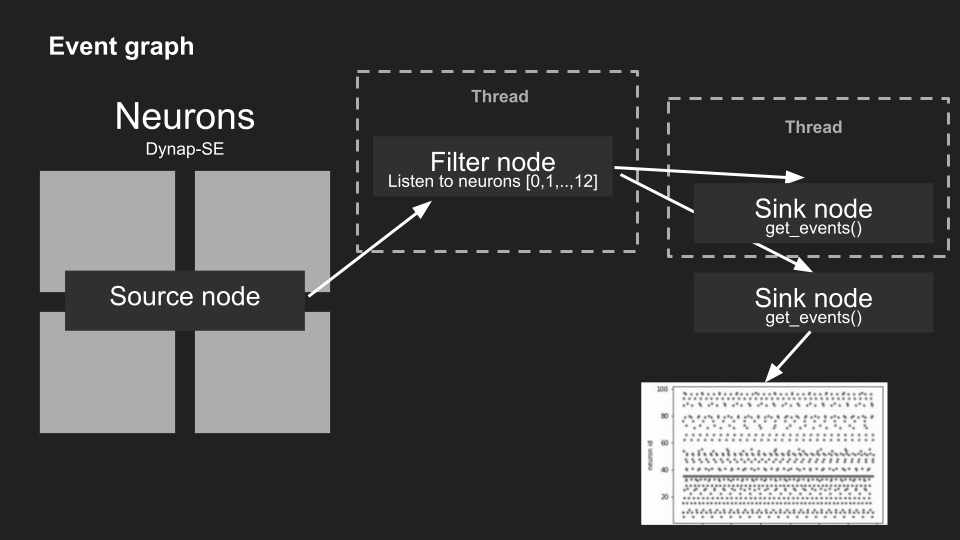

### 3.1 Specifying the neurons we are interested in

IDs go as triplets (chip_id, core_id, n_id)

In [68]:
global_ids = np.array([1,2,3,4,5,6])
neuron_ids = np.array([[1, 0, n_id] for n_id in global_ids])

### 3.2 Create a graph that would give us the events from the specified neurons

In [19]:
graph, filter_node, sink_node = ut.create_neuron_select_graph(model, neuron_ids)


In [ ]:
# Never forget to start the graph!

graph.start()

### 3.3 Let's get some events

The chip is always running, so once the `graph` has been started, the evens from the specified neurons are collected within the buffer. Once the `get_events()` function is called, the events are returned as a list, the buffer is emptied and continues to collect new coming events.

In [27]:
evts = sink_node.get_events()
len(evts)

114

### 3.4 We can edit the filter node on the fly

If you change the list of neurons you record from in the filter node, the spikes from the new set of neurons will be recorded from the moment the function had been executed.

In [35]:
#filter_node.set_neurons(global_ids)
filter_node.set_neurons([[1, 0, n_id] for n_id in np.arange(0,100)])

In [73]:
filter_node.set_neurons(neuron_ids)

In [10]:
# To stop the recording, stop the event graph
# graph.stop()

### Get some events and plot them instantly

Each event in the list has two properties: `timestamp` of the event in **microseconds** since the **last timestamp reset**, stamped by the chip's oboard FPGA; and the `neuron_id`.

In [ ]:
evts = sink_node.get_events()

print(len(evts))
evts_n = np.array([[evt.timestamp, evt.neuron_id] for evt in evts])

plt.plot(evts_n[:,0], evts_n[:,1], '.')
plt.xlabel("time (s)")
plt.ylabel("neuron id")

## 4. Providing input to the chip from the FPGA

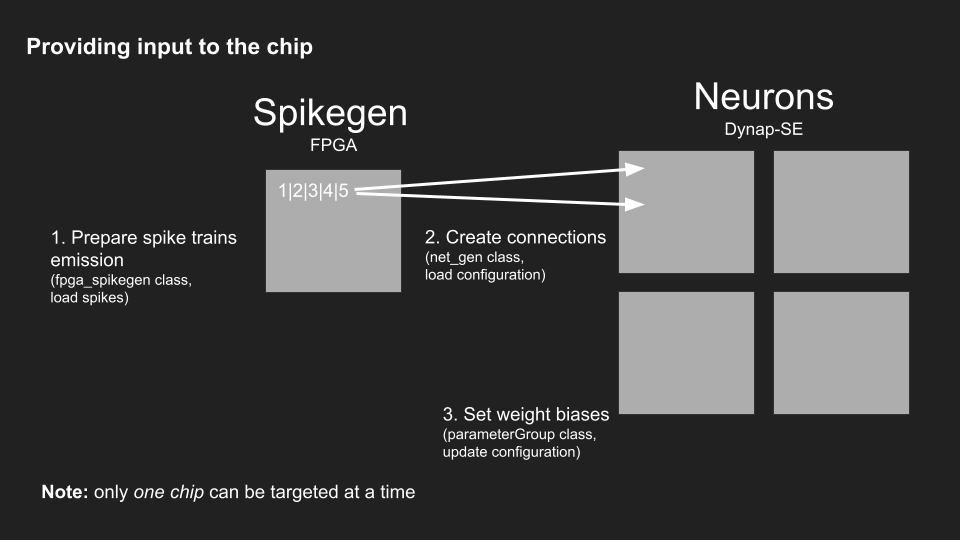

## 4.1 Preparing the spike trains

In [44]:
spikegen_ids = [1, 2]

FPGA limitations for the input spike train:

In [86]:
#Maximum ISI. Can be avoided with dummy spikes
MAX_ISI = 2**ISI_NUM_BITS-1
print(str(MAX_ISI*1e-06 * 10) + " s")

0.65535 s


In [87]:
#Maximum spike train length
MAX_LEN = 2**ADDR_NUM_BITS-1
print(MAX_LEN)

32767


In [89]:
#Spike train of spikegen 1
timestamps1 = np.linspace(0,1,100)
indices1 = np.ones(len(timestamps1))*spikegen_ids[0]

timestamps2 = np.linspace(0,1,200)
indices2 = np.ones(len(timestamps2))*spikegen_ids[1]

Text(0, 0.5, 'spikegen')

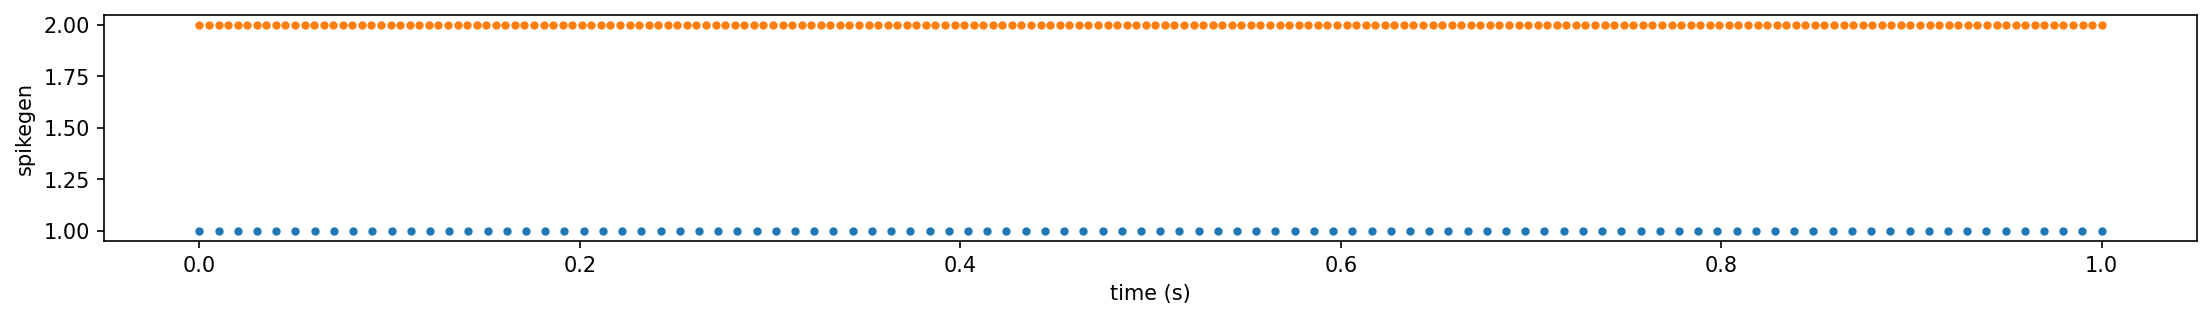

In [90]:
plt.figure(figsize=(18,2), dpi=150)
plt.plot(timestamps1, indices1, '.')
plt.plot(timestamps2, indices2, '.')
plt.xlabel("time (s)")
plt.ylabel("spikegen")

In [91]:
# Create a single SORTED spiketrain

spiketrain = np.concatenate((np.column_stack((timestamps1,indices1)), np.column_stack((timestamps2,indices2))))

In [ ]:
#let's see the result

spiketrain

In [95]:
spiketrain = spiketrain[spiketrain[:,0].argsort()]

Text(0, 0.5, 'spikegen')

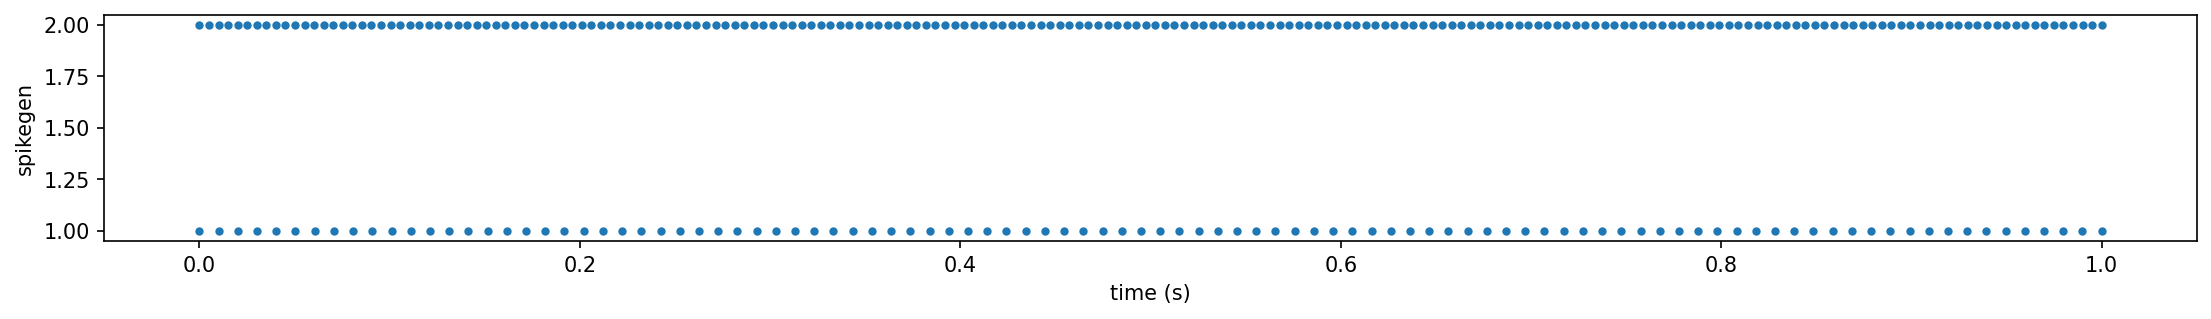

In [96]:
plt.figure(figsize=(18,2), dpi=150)
plt.plot(spiketrain[:,0], spiketrain[:,1], '.')
plt.xlabel("time (s)")
plt.ylabel("spikegen")

In [93]:
fpga_spike_gen = model.get_fpga_spike_gen()
target_chip = 1

In [98]:
ut.set_fpga_spike_gen(fpga_spike_gen, spike_times=spiketrain[:,0], indices=spiketrain[:,1].astype(int), target_chips=[target_chip]*len(spiketrain), isi_base=900, repeat_mode=True)

New configuration applied to DYNAP-SE1!
VariableIsiMode already 1
RepeatMode already 1


In [99]:
fpga_spike_gen.start()

In [97]:
fpga_spike_gen.stop()

### 4.2 Connecting the Spike Generator

In [73]:
import netgen as n
from netgen import Neuron

In [74]:
# if we look at the Neuron object, we see that is has a flag whether it is virtual or not. Virtual neurons are spike emitters on the FPGA
help(Neuron)

Help on class Neuron in module netgen:

class Neuron(builtins.object)
 |  Neuron(chip_id=0, core_id=0, neuron_id=0, is_spike_gen=False)
 |  
 |  Attribute:
 |      chip_id, core_id, neuron_id: int
 |      is_spike_gen: bool, if this neuron is a spike generator on the FPGA or a physical neuron on chip.
 |      incoming_connections: a dictionarty which stores the incoming_connections. Only starts to play a role after add_connection(pre, neuron).
 |          key: tuple, (pre.core_id,pre.neuron_id,synapse_type).
 |              Corresponds to cam. Divide the connections by its cam value for cam reuse.
 |          value: list, [(pre.chip_id, pre.is_spike_gen), (pre.chip_id, pre.is_spike_gen),...].
 |              To tell if the post neurons are the same neuron. get the connection weight.
 |  
 |  Methods defined here:
 |  
 |  __eq__(self, other)
 |      Only compares the ids. Consider a neuron as an individual neuron without any external connections (i.e. not in a Network)
 |  
 |  __hash_

In [57]:
# Let's create 2 virtual neurons

spikegen_neuron1 = Neuron(0,0,1,is_spike_gen=True)
spikegen_neuron2 = Neuron(0,0,2,is_spike_gen=True)

In [54]:
# Let's target neurons 10 and 11

neurons = [Neuron(1,0,10), Neuron(1,0,11)]

In [118]:
# initialize a networkgenerator

net_gen = n.NetworkGenerator()

In [119]:
# All these connections are stored (or 'staged') locally and are not applied to the board right away

#net_gen.add_connection(spikegen_neuron1, neurons[0], dyn1.Dynapse1SynType.AMPA)
net_gen.add_connection(spikegen_neuron1, neurons[0], dyn1.Dynapse1SynType.AMPA)
net_gen.add_connection(spikegen_neuron2, neurons[0], dyn1.Dynapse1SynType.GABA_A)

In [120]:
# print the network so you can double check (optional)
net_gen.print_network()

Post neuron (ChipId,coreId,neuronId): incoming connections [(preNeuron,synapseType), ...]
C1c0n10: [('C0c0s1', 'AMPA'), ('C0c0s2', 'GABA_A')]



In [60]:
net_gen.remove_connection(spikegen_neuron2, neurons[1], dyn1.Dynapse1SynType.AMPA)

In [121]:
# make a dynapse1config using the network
new_config = net_gen.make_dynapse1_configuration()

In [122]:
# apply the configuration
model.apply_configuration(new_config)

### 4.3 Alternative: Poisson spike generator

In [119]:
# poissongen_id, range = [0, 1024)
poissongen_id = 1
rate = 200

# get poissongen from the model
poisson_gen = model.get_poisson_gen()
# set the target chip of the post neurons
post_chip = 1
poisson_gen.set_chip_id(post_chip)
poisson_gen.write_poisson_rate_hz(poissongen_id, rate)

# remember to start the poissongen
poisson_gen.start()

In [120]:
poisson_gen.stop()

## Remember to adjust biases!

Now we can see that we can add and remove connections on the fly

Let's get spikes from those two neurons

In [115]:
filter_node.set_neurons([(1,0,10),(1,0,11)])

In [98]:
graph.start()

False

Spikes collected: 533


Text(0, 0.5, 'neuron id')

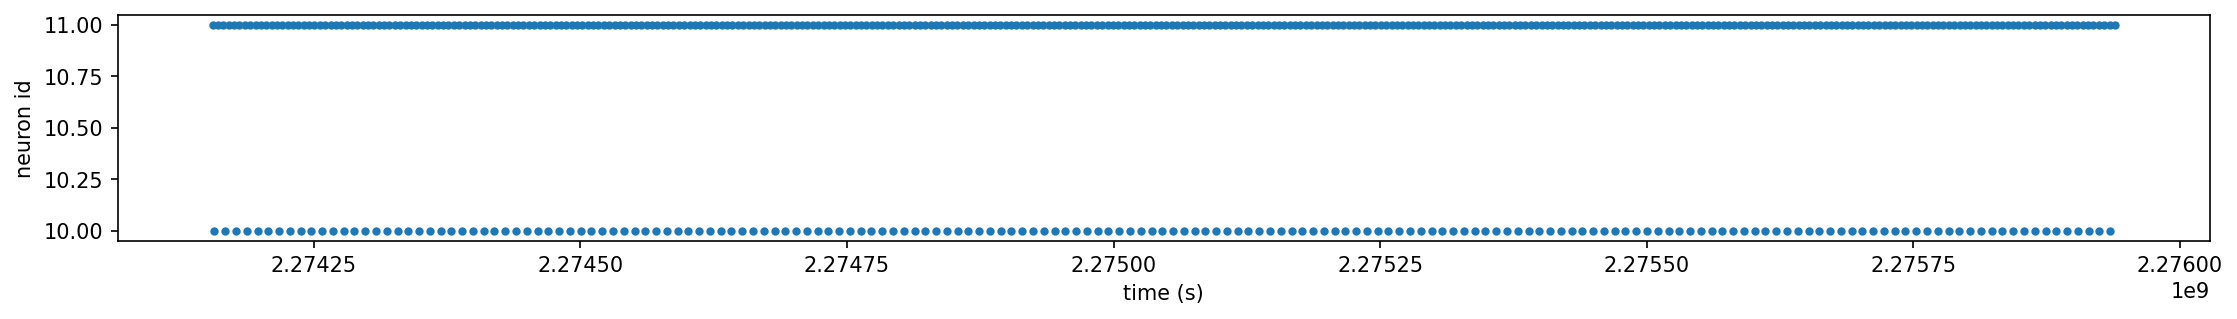

In [128]:
evts = sink_node.get_events()

print("Spikes collected:", len(evts))
evts_n = np.array([[evt.timestamp, evt.neuron_id] for evt in evts])

plt.figure(figsize=(18,2), dpi=150)
plt.plot(evts_n[:,0], evts_n[:,1], '.')
plt.xlabel("time (s)")
plt.ylabel("neuron id")

In [157]:
graph.stop()

True

# What about time varying input?

1257

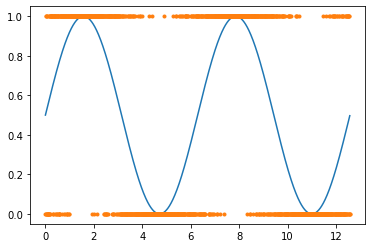

In [76]:
x = np.arange(0,4*np.pi,0.01)
y = np.sin(x)+1
y = y/y.max()
spikes = np.zeros(len(x))
spiketrain = []
for i in range(len(x)):
    if np.random.rand() < y[i]:
        spikes[i]=1

        
fig = plt.figure()
plt.plot(x,y)
plt.plot(x, spikes, '.')

len(spikes)

Text(0, 0.5, 'spikegen')

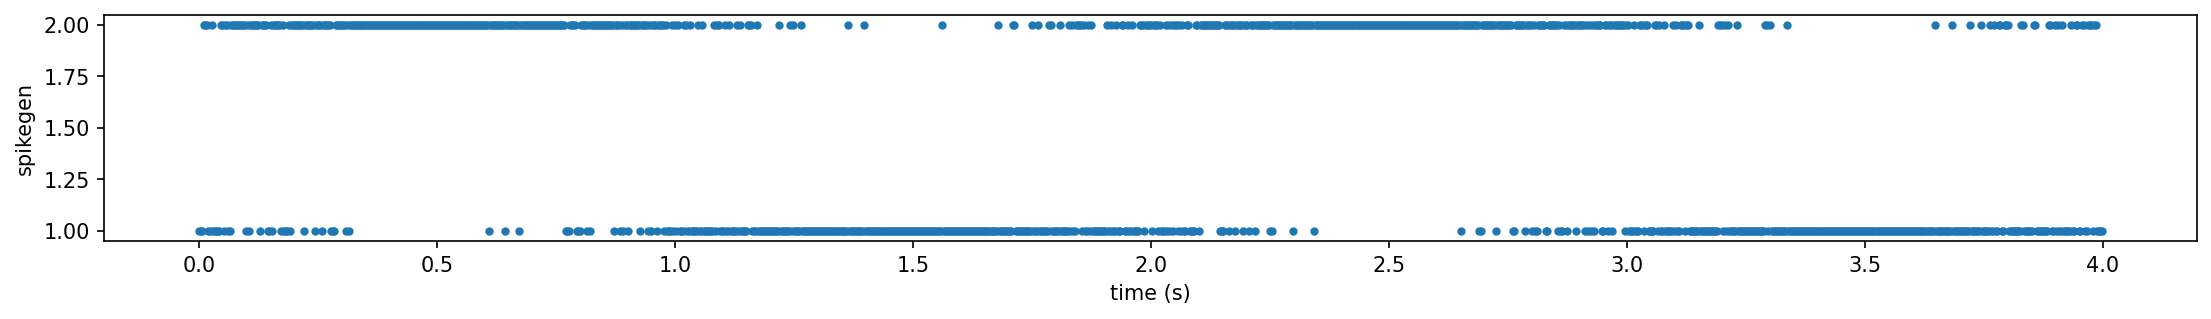

In [77]:
timestamps = 4*x/(4*np.pi)
indices = spikes+1

plt.figure(figsize=(18,2), dpi=150)
plt.plot(timestamps, indices, '.')
plt.xlabel("time (s)")
plt.ylabel("spikegen")

In [80]:
ut.set_fpga_spike_gen(fpga_spike_gen, spike_times=timestamps, indices=indices.astype(int), target_chips=[target_chip]*len(timestamps), isi_base=900, repeat_mode=True)

VariableIsiMode already 1
RepeatMode already 1


In [81]:
fpga_spike_gen.start()

In [79]:
fpga_spike_gen.stop()

### Let's see what all types of synapses are doing

In [82]:
net_gen = n.NetworkGenerator()

In [83]:
net_gen.add_connection(spikegen_neuron1, neurons[0], dyn1.Dynapse1SynType.AMPA)
net_gen.add_connection(spikegen_neuron1, neurons[0], dyn1.Dynapse1SynType.NMDA)
net_gen.add_connection(spikegen_neuron1, neurons[0], dyn1.Dynapse1SynType.GABA_A)
net_gen.add_connection(spikegen_neuron1, neurons[0], dyn1.Dynapse1SynType.GABA_B)

In [84]:
net_gen.print_network()

Post neuron (ChipId,coreId,neuronId): incoming connections [(preNeuron,synapseType), ...]
C1c0n10: [('C0c0s1', 'AMPA'), ('C0c0s1', 'NMDA'), ('C0c0s1', 'GABA_A'), ('C0c0s1', 'GABA_B')]



In [85]:
new_config = net_gen.make_dynapse1_configuration()

In [86]:
model.apply_configuration(new_config)

array([[-0.1     ,  0.742031],
       [-0.0998  ,  0.743594],
       [-0.0996  ,  0.745547],
       ...,
       [ 0.0994  ,  0.706484],
       [ 0.0996  ,  0.707656],
       [ 0.0998  ,  0.708438]])

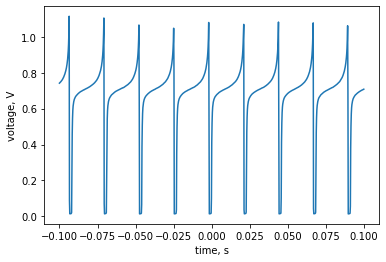

In [13]:
my_scope.get_waveform(channel=1, instant_plot=True)

## We can also automate network changes, right?

In [54]:
import STDP_plotter

neuron_ids = [10,11]

STDP_plotter.run_plotting_thread(neuron_ids, sink_node, refresh_rate = 500)

In [51]:
global_ids = np.array([10, 11])

In [52]:
graph, filter_node, sink_node = ut.create_neuron_select_graph(model, global_ids)

In [53]:
graph.start()

True

### 5 Close the device at the end

In [ ]:
ut.close_dynapse1(store, device_name, gui_process)